![Ironhack logo](https://user-images.githubusercontent.com/23629340/40541063-a07a0a8a-601a-11e8-91b5-2f13e4e6b441.png)

# 01 | Exploratory Data Analysis

*Project 1 — SQL: From Data to Insight*

**Team:** RIZKI, ANDRII
**Dataset:** FAOSTAT – Coffee, green: production (1961–2024), trade (1961–2024), processed (2010–2023)

---

Understanding your data before you design anything. You cannot decide which tables you need until you know which columns repeat, which are broken, and which identify a row.

> **Done when:** you can name the 3+ tables you are going to build, you have written down at least 2 research questions, and you know every data-quality problem notebook 02 will have to fix.

The sections below are a suggested route, not a form to fill in. Add sections, drop them, reorder them — what is graded is the analysis, not whether you kept the scaffold.

---
## 0. Setup

In [47]:
import sys
sys.path.append("..")          # so `src` is importable from inside notebooks/

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from src.functions import *

pd.set_option("display.max_columns", 100)
sns.set_theme(style="whitegrid")
from IPython.display import display, Markdown

---
## 1. Load the raw data

Run `python download_data.py <payments|airbnb|retail>` from the repo root first. Your files land in `data/raw/`, which is gitignored.

In [48]:
"""
Data downloaded manually from FAOSTAT (fao.org/faostat) on 25 Sep 2026 and saved in `data/raw/`.
"""

import os
os.listdir("../data/raw/")

['FAOSTAT_data_en_9-25-2026.csv',
 'FAOSTAT_data_en_9-25-2026 (2).csv',
 '.gitkeep',
 'FAOSTAT_data_en_9-25-2026 (1).csv']

In [49]:
RAW = "../data/raw/"

#production = pd.read_csv(RAW + "FAOSTAT_data_en_9-25-2026.csv", encoding="utf-8-sig")
#trade      = pd.read_csv(RAW + "FAOSTAT_data_en_9-25-2026 (1).csv", encoding="utf-8-sig")
#processed  = pd.read_csv(RAW + "FAOSTAT_data_en_9-25-2026 (2).csv", encoding="utf-8-sig")

print("production:", production.shape)
print("trade:     ", trade.shape)
print("processed: ", processed.shape)

production: (15622, 15)
trade:      (40306, 15)
processed:  (1421, 15)


---
## 2. First look

Shape, column types, a handful of rows. What is one row of this data?

In [50]:
display(production.head())
display(trade.head())
display(processed.head())
production.dtypes

,Domain Code,Domain,Area Code (M49),Area,Element Code,Element,Item Code (CPC),Item,Year Code,Year,Unit,Value,Flag,Flag Description,Note
0,QCL,Crops and livestock products,24,Angola,5312,Area harvested,1610,"Coffee, green",1961,1961,ha,350000.0,A,Official value,NaN
1,QCL,Crops and livestock products,24,Angola,5412,Yield,1610,"Coffee, green",1961,1961,kg/ha,481.7,A,Official value,NaN
2,QCL,Crops and livestock products,24,Angola,5510,Production,1610,"Coffee, green",1961,1961,t,168600.0,A,Official value,NaN
3,QCL,Crops and livestock products,24,Angola,5312,Area harvested,1610,"Coffee, green",1962,1962,ha,500000.0,A,Official value,NaN
4,QCL,Crops and livestock products,24,Angola,5412,Yield,1610,"Coffee, green",1962,1962,kg/ha,370.0,A,Official value,NaN


,Domain Code,Domain,Area Code (M49),Area,Element Code,Element,Item Code (CPC),Item,Year Code,Year,Unit,Value,Flag,Flag Description,Note
0,TCL,Crops and livestock products,4,Afghanistan,5610,Import quantity,1610,"Coffee, green",1961,1961,t,0.0,A,Official value,NaN
1,TCL,Crops and livestock products,4,Afghanistan,5622,Import value,1610,"Coffee, green",1961,1961,1000 USD,0.0,A,Official value,NaN
2,TCL,Crops and livestock products,4,Afghanistan,5610,Import quantity,1610,"Coffee, green",1962,1962,t,0.0,A,Official value,NaN
3,TCL,Crops and livestock products,4,Afghanistan,5622,Import value,1610,"Coffee, green",1962,1962,1000 USD,0.0,A,Official value,NaN
4,TCL,Crops and livestock products,4,Afghanistan,5610,Import quantity,1610,"Coffee, green",1963,1963,t,0.0,A,Official value,NaN


,Domain Code,Domain,Area Code (M49),Area,Element Code,Element,Item Code (CPC),Item,Year Code,Year,Unit,Value,Flag,Flag Description,Note
0,SCL,Supply Utilization Accounts (2010-),8,Albania,5023,Processed,1610,"Coffee, green",2010,2010,t,4642.00,E,Estimated value,NaN
1,SCL,Supply Utilization Accounts (2010-),8,Albania,5023,Processed,1610,"Coffee, green",2011,2011,t,4922.00,E,Estimated value,NaN
2,SCL,Supply Utilization Accounts (2010-),8,Albania,5023,Processed,1610,"Coffee, green",2012,2012,t,5189.00,E,Estimated value,NaN
3,SCL,Supply Utilization Accounts (2010-),8,Albania,5023,Processed,1610,"Coffee, green",2013,2013,t,5216.00,E,Estimated value,NaN
4,SCL,Supply Utilization Accounts (2010-),8,Albania,5023,Processed,1610,"Coffee, green",2014,2014,t,4199.23,E,Estimated value,NaN


Domain Code          object
Domain               object
Area Code (M49)       int64
Area                 object
Element Code          int64
Element              object
Item Code (CPC)       int64
Item                 object
Year Code             int64
Year                  int64
Unit                 object
Value               float64
Flag                 object
Flag Description     object
Note                 object
dtype: object

---
## 3. Data quality

Missing values, duplicates, numbers stored as text, dates stored as strings. Write down what you find — this is the to-do list for notebook 02.

In [51]:
for name, df in {"production": production, "trade": trade, "processed": processed}.items():
    dup = df.duplicated(["Area Code (M49)", "Year", "Element Code"]).sum()
    print(f"{name}: duplicate (country, year, element) = {dup}")

production: duplicate (country, year, element) = 0
trade: duplicate (country, year, element) = 0
processed: duplicate (country, year, element) = 0


In [52]:
p = set(production["Area Code (M49)"])
t = set(trade["Area Code (M49)"])
s = set(processed["Area Code (M49)"])

print("Countries in production but not in trade:", production[production["Area Code (M49)"].isin(p - t)]["Area"].unique())
print("Countries in processed but not in trade:", len(s - t))
print("Total different countries across all files:", len(p | t | s))

Countries in production but not in trade: ['Guadeloupe' 'Martinique' 'Puerto Rico']
Countries in processed but not in trade: 0
Total different countries across all files: 209


In [53]:
exp_qty = trade[trade["Element"] == "Export quantity"]
print("Export quantity = 0:", (exp_qty["Value"] == 0).sum())
print("Export quantity under 1 tonne:", (exp_qty["Value"] < 1).sum())

Export quantity = 0: 2130
Export quantity under 1 tonne: 2360


**To-do list for notebook 02**
- Drop rows flagged M (267 production rows with no value)
- Drop "China" (code 159): it is a total of mainland + Taiwan + Hong Kong + Macao → double counting
- Drop columns we don't need: `Domain Code`, `Domain`, `Item Code (CPC)`, `Item`, `Year Code`, `Note`
- Primary key for each table: (area_code, year, element_code). There are no duplicates.
- The `countries` table must be built from all 3 files (209 countries), because 3 producers are missing from trade
- Price per kg: ignore export/import quantities of 0 or under a minimum (e.g. 1,000 t), otherwise prices are wrong
- Many values are estimates (E, I, X) → keep them, but mention it as a limitation

---
## 4. Distributions

The numeric columns you care about, and the outliers you will have to decide about.

In [54]:
production.groupby("Element")["Value"].describe()

,count,mean,std,min,25%,50%,75%,max
Element,,,,,,,,
Area harvested,5157.0,127994.809385,328732.851285,0.0,730.00,14242.0,113443.00,4462657.0
Production,5191.0,82272.231476,268012.121301,0.0,362.38,7140.0,56998.50,3705719.0
Yield,5007.0,653.497184,589.043416,5.6,319.00,509.0,830.35,13333.3


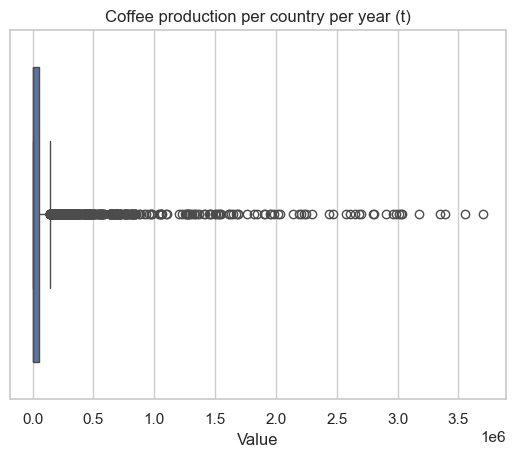

In [55]:
prod_only = production[production["Element"] == "Production"]
sns.boxplot(x=prod_only["Value"])
plt.title("Coffee production per country per year (t)")
plt.show()

In [56]:
trade.groupby("Element")["Value"].describe()

,count,mean,std,min,25%,50%,75%,max
Element,,,,,,,,
Export quantity,9240.0,34621.191444,144180.171069,0.0,0.5275,249.055,7891.25,2768767.08
Export value,9279.0,77818.022093,367110.430431,0.0,2.0000,529.000,14970.50,11337478.00
Import quantity,10859.0,29030.966537,123144.815032,0.0,2.0000,154.000,9640.50,1592249.37
Import value,10928.0,71256.061951,343988.303000,0.0,7.0000,289.000,15447.00,7888644.00


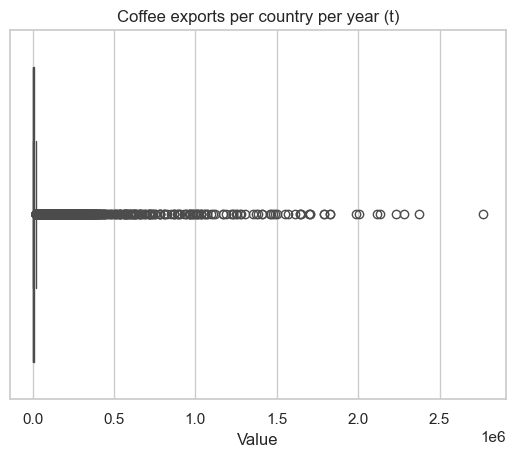

In [57]:
exports = trade[trade["Element"] == "Export quantity"]
sns.boxplot(x=exports["Value"])
plt.title("Coffee exports per country per year (t)")
plt.show()

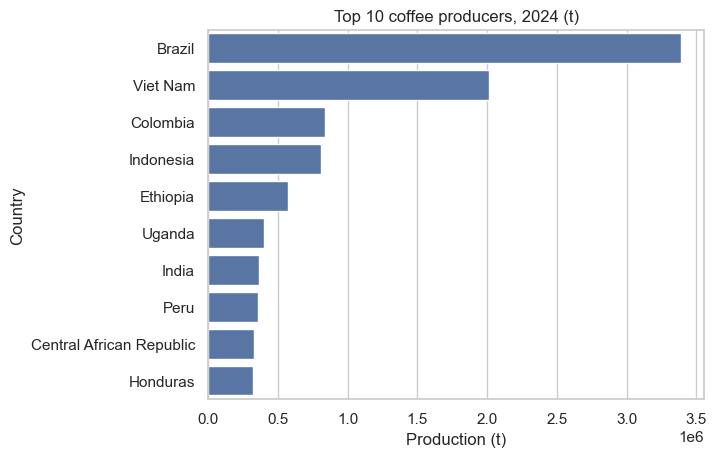

In [58]:
top10 = prod_only[prod_only["Year"] == 2024].nlargest(10, "Value")

sns.barplot(data=top10, x="Value", y="Area")
plt.title("Top 10 coffee producers, 2024 (t)")
plt.xlabel("Production (t)")
plt.ylabel("Country")
plt.show()

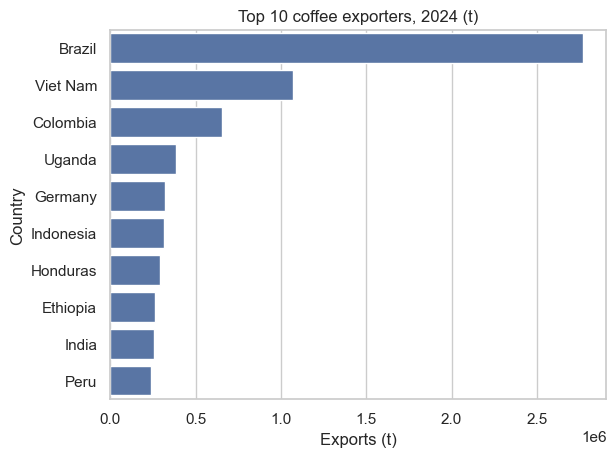

In [59]:
top10_exp = exports[exports["Year"] == 2024].nlargest(10, "Value")

sns.barplot(data=top10_exp, x="Value", y="Area")
plt.title("Top 10 coffee exporters, 2024 (t)")
plt.xlabel("Exports (t)")
plt.ylabel("Country")
plt.show()

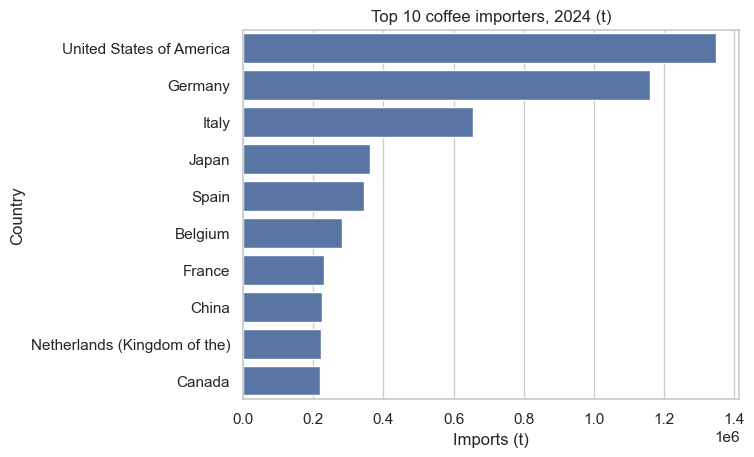

In [60]:
imports = trade[trade["Element"] == "Import quantity"]
top10_imp = imports[imports["Year"] == 2024].nlargest(10, "Value")

sns.barplot(data=top10_imp, x="Value", y="Area")
plt.title("Top 10 coffee importers, 2024 (t)")
plt.xlabel("Imports (t)")
plt.ylabel("Country")
plt.show()

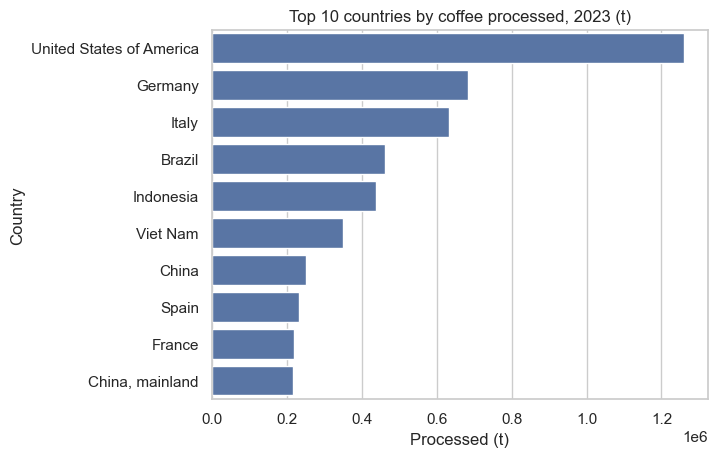

In [61]:
top10_proc = processed[processed["Year"] == 2023].nlargest(10, "Value")

sns.barplot(data=top10_proc, x="Value", y="Area")
plt.title("Top 10 countries by coffee processed, 2023 (t)")
plt.xlabel("Processed (t)")
plt.ylabel("Country")
plt.show()

- Values are very skewed: a few countries (Brazil, Viet Nam) are much bigger than the rest. These outliers are real, so I keep them.
- Importers include non-producers (Germany, Belgium) that import and re-export.
- The biggest processors are consumer countries, not producers.

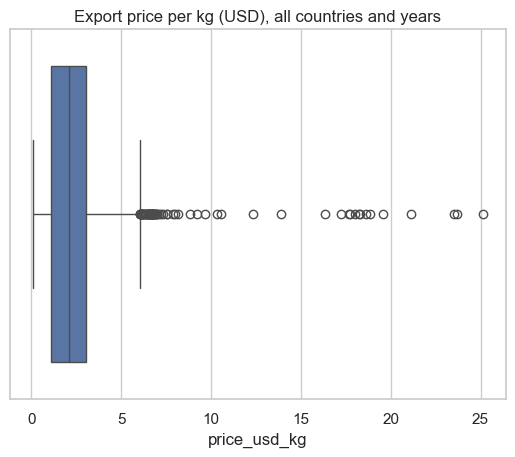

count    3709.000000
mean        2.334199
std         1.788707
min         0.061985
25%         1.071429
50%         2.074372
75%         3.064763
max        25.160119
Name: price_usd_kg, dtype: float64

In [62]:
exp = trade[trade["Element"].isin(["Export quantity", "Export value"])] \
        .pivot_table(index=["Area", "Year"], columns="Element", values="Value")
exp = exp[exp["Export quantity"] >= 1000]          # only real exporters
exp["price_usd_kg"] = exp["Export value"] / exp["Export quantity"]

sns.boxplot(x=exp["price_usd_kg"])
plt.title("Export price per kg (USD), all countries and years")
plt.show()

exp["price_usd_kg"].describe()

Price per kg = value (1000 USD) ÷ quantity (t) = USD/kg, no conversion needed
- Without a minimum quantity, tiny shipments give extreme prices → use a minimum of 1,000 t in the SQL queries
- Production and trade values are very skewed (Brazil, Viet Nam). These outliers are real, so I keep them.

---
## 5. Categorical columns

**This is the section that feeds tomorrow.** A column with few distinct values repeated over many rows is a lookup table waiting to happen. Find them.

In [63]:
for name, df in {"production": production, "trade": trade, "processed": processed}.items():
    print(f"{name} ({len(df):,} rows)")
    print(df.nunique().sort_values())
    print()

production (15,622 rows)
Domain Code            1
Domain                 1
Item Code (CPC)        1
Item                   1
Note                   1
Element Code           3
Element                3
Unit                   3
Flag                   5
Flag Description       5
Year Code             64
Year                  64
Area Code (M49)       86
Area                  86
Value               9399
dtype: int64

trade (40,306 rows)
Domain Code             1
Domain                  1
Item Code (CPC)         1
Item                    1
Note                    1
Unit                    2
Element Code            4
Element                 4
Flag                    4
Flag Description        4
Year Code              64
Year                   64
Area Code (M49)       206
Area                  206
Value               17073
dtype: int64

processed (1,421 rows)
Note                   0
Domain Code            1
Domain                 1
Element Code           1
Element                1
Item Code (CPC

In [64]:
all_data = pd.concat([production, trade, processed])

display(all_data[["Element Code", "Element", "Unit"]].drop_duplicates())
display(all_data[["Flag", "Flag Description"]].drop_duplicates())
display(all_data[["Area Code (M49)", "Area"]].drop_duplicates().head(10))

,Element Code,Element,Unit
0,5312,Area harvested,ha
1,5412,Yield,kg/ha
2,5510,Production,t
0,5610,Import quantity,t
1,5622,Import value,1000 USD
120,5910,Export quantity,t
121,5922,Export value,1000 USD
0,5023,Processed,t


,Flag,Flag Description
0,A,Official value
6,E,Estimated value
44,X,Value from external organization
150,I,Value imputed by a receiving agency
192,M,Missing value; data cannot exist


,Area Code (M49),Area
0,24,Angola
192,84,Belize
287,204,Benin
479,68,Bolivia (Plurinational State of)
671,76,Brazil
863,108,Burundi
1055,132,Cabo Verde
1228,116,Cambodia
1420,120,Cameroon
1612,140,Central African Republic


**Lookup tables found**
- countries: `Area Code (M49)`, `Area`
- elements: `Element Code`, `Element`, `Unit`
- flags: `Flag`, `Flag Description`

`Domain` and `Item` have only one value, so they don't need a table.

---
## 6. Research questions

At least two, written here. Specific, answerable with this data, and with an answer you could be wrong about. For each one, say what you expect and why.

NEW:
**1. Do countries with more coffee land (area harvested) or higher yield (kg/ha) sell their green coffee at a lower export price per kg?**

*Hypothesis:* Large, high-yield producers such as Brazil and Viet Nam sell cheaper than smaller, low-yield producers such as Ethiopia and Kenya, because better technology and scale lower the cost per kg.
*How we test it:* For each producing country per year, calculate yield (kg/ha) and export price (export value ÷ export quantity, in USD/kg), then measure the correlation between area harvested, yield and export price.
*We could be wrong if:* the type and quality of coffee (arabica vs robusta) explains price better than land or yield. The data does not split coffee by type, so this is a limitation.

**2. Do coffee-consuming countries pay more per kg for green coffee than coffee-producing countries receive for it?**

*Hypothesis:* The import price per kg paid by non-producing countries (e.g. Germany, the Netherlands, the USA) is higher than the export price per kg received by producing countries (e.g. Brazil, Viet Nam, Ethiopia), and the gap has grown over time.
*How we test it:* Classify each country as a *producer* (production > 0 in the production table) or a *consumer* (no production). Calculate the import price (import value ÷ import quantity) for consumers and the export price (export value ÷ export quantity) for producers, per year, and compare them using SQLite and Python.
*We could be wrong if:* the gap is small. Both prices are for unroasted green coffee, so the difference may only reflect shipping and insurance, not the big price increase that comes later with roasting and retail.

OLD:
1. IWW can data analytics and forecasting models, built on historical production, area, yield and trade data, help predict future coffee supply and export flows?How might we help farmers produce more coffee from existing land in a sustainable way?
2. How might we help farmers produce more coffee from existing land in a sustainable way?

Element         Area harvested     Yield  price_usd_kg
Element                                               
Area harvested        1.000000 -0.240602     -0.190977
Yield                -0.240602  1.000000     -0.039098
price_usd_kg         -0.190977 -0.039098      1.000000


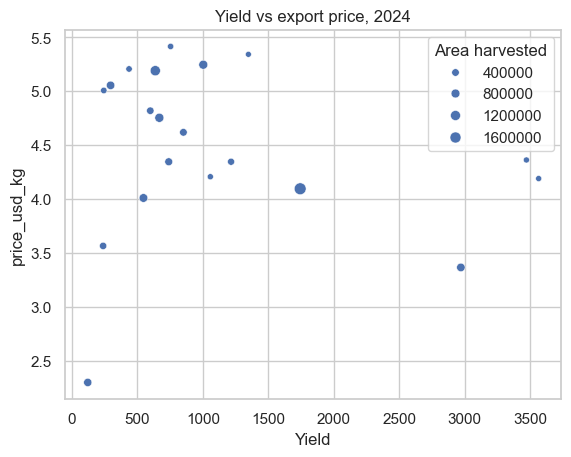

In [65]:
p24 = production[production["Year"] == 2024].pivot_table(index="Area", columns="Element", values="Value")
t24 = trade[trade["Year"] == 2024].pivot_table(index="Area", columns="Element", values="Value")

df = p24.join(t24, how="inner")
df["price_usd_kg"] = df["Export value"] / df["Export quantity"]
df = df[df["Export quantity"] > 20000]      # only real exporters

print(df[["Area harvested", "Yield", "price_usd_kg"]].corr(method="spearman"))

sns.scatterplot(data=df, x="Yield", y="price_usd_kg", size="Area harvested")
plt.title("Yield vs export price, 2024")
plt.show()

---
## 7. Into notebook 02

The tables you are going to build, and the problems you have to fix first.

**Tables to build**
- `countries` (area_code, area_name)
- `elements` (element_code, element_name, unit)
- `flags` (flag, flag_description)
- `production` (area_code, year, element_code, value, flag)
- `trade` (area_code, year, element_code, value, flag)
- `processed` (area_code, year, element_code, value, flag)

**Fix first:** see the to-do list in section 3.